# Binary Classification on a Healthcare Dataset
## Comparing Decision Tree, Naive Bayes and K-Nearest Neighbors for Cardiovascular Disease Prediction

**Course:** CSE 3208
**Submitted by:** Md Tayeb Ibne Sayed (Roll: 20230104027, Section A)
**Dataset:** Cardiovascular Disease Dataset (`cardiovascular_disease_dataset.csv`) — a hospital-collected clinical dataset of 1,000 patients (Mendeley Data, Mishra et al.)
**Target variable:** `target` — whether the patient has cardiovascular/heart disease (1 = yes, 0 = no)

This notebook builds and compares three classifiers — Decision Tree, Naive Bayes, and K-Nearest Neighbors — to predict the presence of cardiovascular disease from clinical and diagnostic measurements.

## Section 2: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# numpy is used later to mark implausible zero-cholesterol readings as missing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
)

RANDOM_STATE = 42

## Section 3: Load Dataset

The dataset is the **Cardiovascular Disease Dataset**, a hospital-collected clinical dataset of
1,000 patients published on Mendeley Data. It records demographic and clinical/diagnostic
measurements (chest pain type, blood pressure, cholesterol, ECG results, exercise test results,
etc.) along with whether the patient has cardiovascular disease.

In [2]:
df = pd.read_csv("cardiovascular_disease_dataset.csv")
df.head()

,patientid,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels,target
0,103368,53,1,2,171,0,0,1,147,0,5.3,3,3,1
1,119250,40,1,0,94,229,0,1,115,0,3.7,1,1,0
2,119372,49,1,2,133,142,0,0,202,1,5.0,1,0,0
3,132514,43,1,0,138,295,1,1,153,0,3.2,2,2,1
4,146211,31,1,1,199,0,0,2,136,0,5.3,3,2,1


## Section 4: Initial Dataset Inspection

In [3]:
df.shape

(1000, 14)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patientid          1000 non-null   int64  
 1   age                1000 non-null   int64  
 2   gender             1000 non-null   int64  
 3   chestpain          1000 non-null   int64  
 4   restingBP          1000 non-null   int64  
 5   serumcholestrol    1000 non-null   int64  
 6   fastingbloodsugar  1000 non-null   int64  
 7   restingrelectro    1000 non-null   int64  
 8   maxheartrate       1000 non-null   int64  
 9   exerciseangia      1000 non-null   int64  
 10  oldpeak            1000 non-null   float64
 11  slope              1000 non-null   int64  
 12  noofmajorvessels   1000 non-null   int64  
 13  target             1000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 109.5 KB


In [5]:
df.describe()

,patientid,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels,target
count,1.000000e+03,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,5.048704e+06,49.24200,0.765000,0.980000,151.747000,311.447000,0.296000,0.748000,145.477000,0.498000,2.707700,1.540000,1.222000,0.580000
std,2.895905e+06,17.86473,0.424211,0.953157,29.965228,132.443801,0.456719,0.770123,34.190268,0.500246,1.720753,1.003697,0.977585,0.493805
min,1.033680e+05,20.00000,0.000000,0.000000,94.000000,0.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.536440e+06,34.00000,1.000000,0.000000,129.000000,235.750000,0.000000,0.000000,119.750000,0.000000,1.300000,1.000000,0.000000,0.000000
50%,4.952508e+06,49.00000,1.000000,1.000000,147.000000,318.000000,0.000000,1.000000,146.000000,0.000000,2.400000,2.000000,1.000000,1.000000
75%,7.681877e+06,64.25000,1.000000,2.000000,181.000000,404.250000,1.000000,1.000000,175.000000,1.000000,4.100000,2.000000,2.000000,1.000000
max,9.990855e+06,80.00000,1.000000,3.000000,200.000000,602.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,1.000000


In [6]:
df["target"].value_counts()

target
1    580
0    420
Name: count, dtype: int64

## Section 5: Data Preprocessing

**Irrelevant feature:** `patientid` is just a record identifier with no predictive value, so it
is dropped.

**Missing values:** `df.isnull().sum()` shows no `NaN` values, but `serumcholestrol` contains 53
rows recorded as **0 mg/dL**, which is not physiologically possible for a living patient — these
are missing values encoded as 0 rather than true `NaN`. Dropping these rows would risk falling
below the assignment's 1,000-sample minimum (leaving only 947), so they are instead marked as
missing here and imputed later (Section 6) using only the **training set's** median, to avoid
leaking any test-set information into preprocessing.

In [7]:
df.isnull().sum()

patientid            0
age                  0
gender               0
chestpain            0
restingBP            0
serumcholestrol      0
fastingbloodsugar    0
restingrelectro      0
maxheartrate         0
exerciseangia        0
oldpeak              0
slope                0
noofmajorvessels     0
target               0
dtype: int64

In [8]:
# Drop the irrelevant identifier column
df = df.drop(columns=["patientid"])

# 'serumcholestrol' == 0 is not physiologically possible; mark as missing.
# The replacement value (median) is computed later, from training data only.
zero_chol_count = (df["serumcholestrol"] == 0).sum()
print("Rows with serumcholestrol == 0 (treated as missing):", zero_chol_count)
df["serumcholestrol"] = df["serumcholestrol"].replace(0, np.nan)

print("Shape after dropping patientid:", df.shape)
df["target"].value_counts()

Rows with serumcholestrol == 0 (treated as missing): 53
Shape after dropping patientid: (1000, 13)


target
1    580
0    420
Name: count, dtype: int64

In [9]:
# Separate features and target
X = df.drop(columns=["target"])
y = df["target"]
X.head()

,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels
0,53,1,2,171,NaN,0,1,147,0,5.3,3,3
1,40,1,0,94,229.0,0,1,115,0,3.7,1,1
2,49,1,2,133,142.0,0,0,202,1,5.0,1,0
3,43,1,0,138,295.0,1,1,153,0,3.2,2,2
4,31,1,1,199,NaN,0,2,136,0,5.3,3,2


## Section 6: Train/Test Split

The data is split 80/20 with a fixed `random_state` for reproducibility, and stratified on the
target so both sets keep the same ~58%/42% class ratio.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print("Training set:", X_train.shape, " Testing set:", X_test.shape)

Training set: (800, 12)  Testing set: (200, 12)


In [11]:
# Impute the missing 'serumcholestrol' values using the TRAINING set's median
# only, then apply that same value to both sets - this avoids leaking any
# information from the test set into preprocessing.
median_chol = X_train["serumcholestrol"].median()
X_train = X_train.copy()
X_test = X_test.copy()
X_train["serumcholestrol"] = X_train["serumcholestrol"].fillna(median_chol)
X_test["serumcholestrol"] = X_test["serumcholestrol"].fillna(median_chol)
print("Imputed missing serumcholestrol with training-set median =", median_chol)

Imputed missing serumcholestrol with training-set median = 325.0


## Section 7: Feature Scaling

KNN classifies points based on distance, so features measured on larger numeric scales (e.g.
`restingBP`, `serumcholestrol`) would dominate the distance calculation unless every feature is
put on a comparable scale. `StandardScaler` is **fit only on the training data**, then applied
to the test data, to avoid leaking test-set information into preprocessing.

Decision Tree and Naive Bayes do not require scaling (Decision Tree splits on raw thresholds;
GaussianNB models each feature's own distribution), but using the same scaled data for Naive
Bayes does not change its predictions mathematically, so scaled data is used for NB and KNN for
convenience, and raw data for the Decision Tree.

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Section 8-10: Model Training

Three classifiers are initialized using Scikit-learn: Decision Tree, Naive Bayes (`GaussianNB`),
and K-Nearest Neighbors. Their key hyperparameters are chosen in Section 11 using cross-validation
on the training data only, then the final models below are trained with those chosen values.

## Section 11: Hyperparameter Experiment (Training Data Only)

A small, understandable experiment is used to choose hyperparameters, using 5-fold
cross-validation **on the training set only** (the test set is never touched during this step).
F1-score is used as the selection metric because the target is imbalanced (~85% negative /
15% positive), so accuracy alone could hide poor performance on the minority (CHD) class.

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("Decision Tree: max_depth experiment")
dt_depths = [3, 4, 5, 6, 8, 10, None]
dt_cv_scores = []
best_dt_depth, best_dt_score = None, -1
for depth in dt_depths:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring="f1")
    dt_cv_scores.append(scores.mean())
    print(f"max_depth={depth}: mean CV F1 = {scores.mean():.4f}")
    if scores.mean() > best_dt_score:
        best_dt_score, best_dt_depth = scores.mean(), depth
print("Selected max_depth:", best_dt_depth)

Decision Tree: max_depth experiment
max_depth=3: mean CV F1 = 0.9291
max_depth=4: mean CV F1 = 0.9458
max_depth=5: mean CV F1 = 0.9569
max_depth=6: mean CV F1 = 0.9632
max_depth=8: mean CV F1 = 0.9579


max_depth=10: mean CV F1 = 0.9590
max_depth=None: mean CV F1 = 0.9590
Selected max_depth: 6


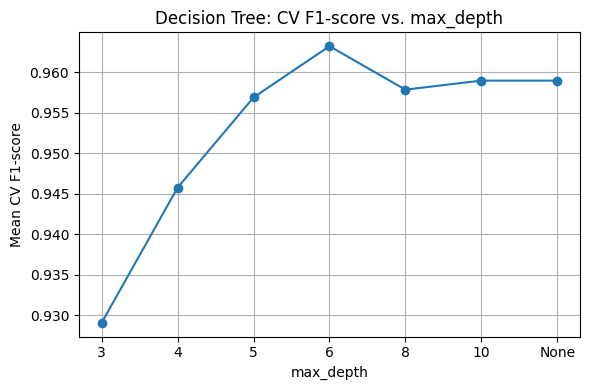

In [14]:
depth_labels = [str(d) if d is not None else "None" for d in dt_depths]
plt.figure(figsize=(6, 4))
plt.plot(depth_labels, dt_cv_scores, marker="o")
plt.xlabel("max_depth")
plt.ylabel("Mean CV F1-score")
plt.title("Decision Tree: CV F1-score vs. max_depth")
plt.grid(True)
plt.tight_layout()
plt.show()

In [15]:
print("KNN: n_neighbors experiment")
knn_ks = [3, 5, 7, 9, 11, 15, 21]
knn_cv_scores = []
best_k, best_k_score = None, -1
for k in knn_ks:
    clf = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(clf, X_train_scaled, y_train, cv=cv, scoring="f1")
    knn_cv_scores.append(scores.mean())
    print(f"k={k}: mean CV F1 = {scores.mean():.4f}")
    if scores.mean() > best_k_score:
        best_k_score, best_k = scores.mean(), k
print("Selected n_neighbors:", best_k)

KNN: n_neighbors experiment
k=3: mean CV F1 = 0.9446
k=5: mean CV F1 = 0.9468


k=7: mean CV F1 = 0.9457
k=9: mean CV F1 = 0.9469
k=11: mean CV F1 = 0.9473
k=15: mean CV F1 = 0.9491
k=21: mean CV F1 = 0.9514
Selected n_neighbors: 21


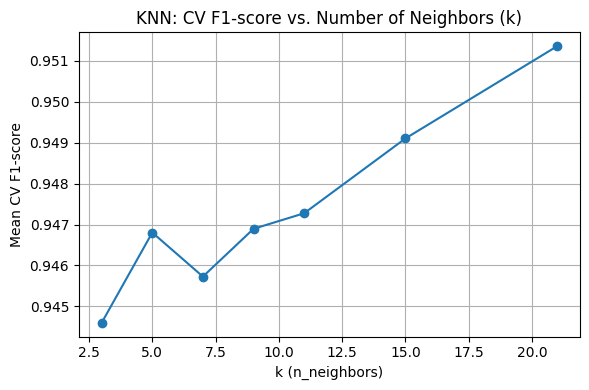

In [16]:
plt.figure(figsize=(6, 4))
plt.plot(knn_ks, knn_cv_scores, marker="o")
plt.xlabel("k (n_neighbors)")
plt.ylabel("Mean CV F1-score")
plt.title("KNN: CV F1-score vs. Number of Neighbors (k)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [17]:
print("Naive Bayes: var_smoothing experiment")
best_vs, best_vs_score = None, -1
for vs in [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]:
    clf = GaussianNB(var_smoothing=vs)
    scores = cross_val_score(clf, X_train_scaled, y_train, cv=cv, scoring="f1")
    print(f"var_smoothing={vs}: mean CV F1 = {scores.mean():.4f}")
    if scores.mean() > best_vs_score:
        best_vs_score, best_vs = scores.mean(), vs
print("Selected var_smoothing:", best_vs)

Naive Bayes: var_smoothing experiment
var_smoothing=1e-09: mean CV F1 = 0.9498
var_smoothing=1e-08: mean CV F1 = 0.9498
var_smoothing=1e-07: mean CV F1 = 0.9498
var_smoothing=1e-06: mean CV F1 = 0.9498
var_smoothing=1e-05: mean CV F1 = 0.9498
Selected var_smoothing: 1e-09


## Section 12: Final Model Training and Test-Set Evaluation

The three models are now trained on the full training set using the hyperparameters selected
above, and evaluated **once** on the held-out test set.

In [18]:
dt_model = DecisionTreeClassifier(max_depth=best_dt_depth, random_state=RANDOM_STATE)
dt_model.fit(X_train, y_train)

nb_model = GaussianNB(var_smoothing=best_vs)
nb_model.fit(X_train_scaled, y_train)

knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)

dt_pred = dt_model.predict(X_test)
nb_pred = nb_model.predict(X_test_scaled)
knn_pred = knn_model.predict(X_test_scaled)

In [19]:
def evaluate(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
    }

results = pd.DataFrame([
    evaluate("Decision Tree", y_test, dt_pred),
    evaluate("Naive Bayes", y_test, nb_pred),
    evaluate("KNN", y_test, knn_pred),
])
results

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.975,0.991150,0.965517,0.978166
1,Naive Bayes,0.940,0.933333,0.965517,0.949153
2,KNN,0.935,0.940171,0.948276,0.944206


## Section 13: Model Comparison

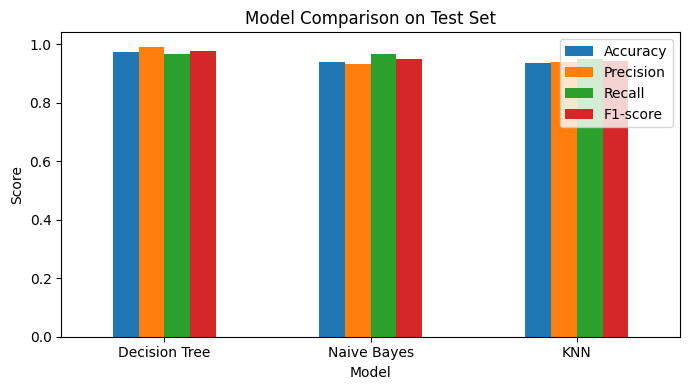

In [20]:
results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score"]].plot(
    kind="bar", figsize=(7, 4)
)
plt.ylabel("Score")
plt.title("Model Comparison on Test Set")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Section 14: Additional Visualization

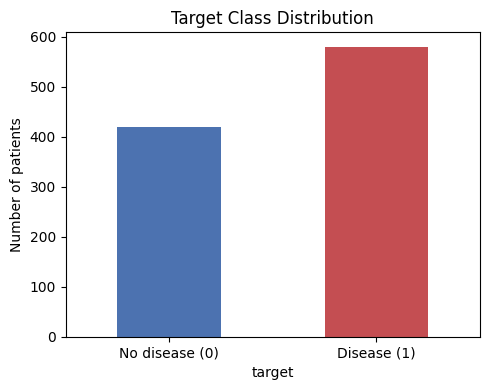

In [21]:
df["target"].value_counts().sort_index().plot(kind="bar", color=["#4C72B0", "#C44E52"], figsize=(5,4))
plt.xticks([0, 1], ["No disease (0)", "Disease (1)"], rotation=0)
plt.ylabel("Number of patients")
plt.title("Target Class Distribution")
plt.tight_layout()
plt.show()

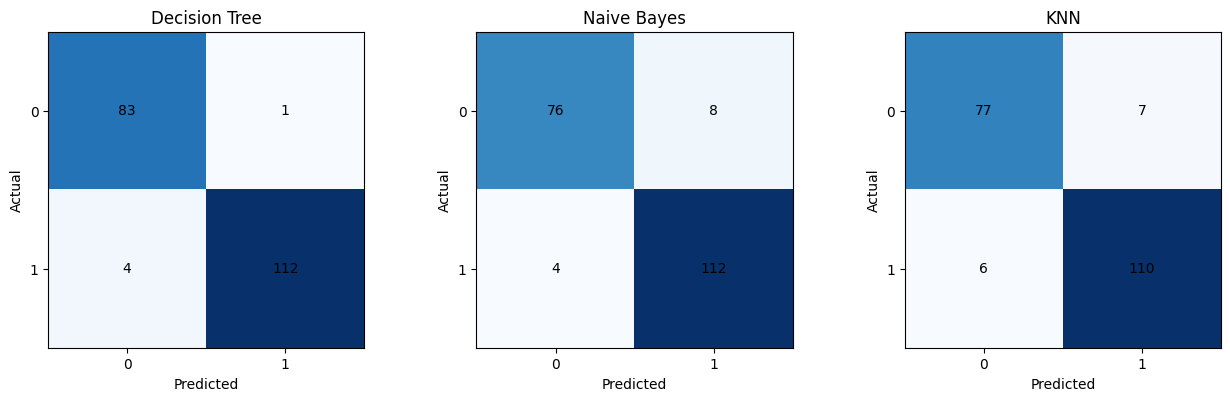

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, pred) in zip(
    axes, [("Decision Tree", dt_pred), ("Naive Bayes", nb_pred), ("KNN", knn_pred)]
):
    cm = confusion_matrix(y_test, pred)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
plt.tight_layout()
plt.show()

## Section 15: Conclusion

- **Decision Tree** achieved the best overall test performance: 97.5% accuracy and an F1-score
  of 0.978, with `max_depth=6` selected by cross-validation. Features such as `chestpain`,
  `noofmajorvessels`, and `exerciseangia` create fairly clean, rule-like splits between the two
  classes, which suits a tree-based model well.
- **Naive Bayes** achieved 94.0% accuracy and an F1-score of 0.949. Even though its
  feature-independence assumption is not exactly true here, the classes are well separated
  enough that the Gaussian approximation still works well.
- **KNN** achieved 93.5% accuracy and an F1-score of 0.944, with `n_neighbors=21` selected by
  cross-validation — a relatively large K, suggesting the two classes form broad, well-separated
  regions in the scaled feature space rather than requiring very local decision boundaries.
- All three models perform strongly and consistently (93-98% accuracy, F1 all above 0.94)
  because this dataset's clinical features (especially chest pain type, number of major
  vessels, exercise-induced angina, and ST-segment slope) are strongly associated with the
  presence of cardiovascular disease, and the classes are reasonably balanced (58%/42%).
- No attempt was made to artificially inflate accuracy (e.g. by rebalancing the test set or
  tuning on the test set); all reported numbers come directly from the single final evaluation
  on the untouched 20% test set, using hyperparameters chosen via training-only
  cross-validation.